<a href="https://colab.research.google.com/github/manika-lamba/SP26-LIS4_5693/blob/main/lab-assignments/lab-7/Lab_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab-7 Sentiment Analysis

## Learning Objectives

- Load your dataset file from GitHub.
- Clean and preprocess text for sentiment analysis.
- Generate sentiment polarity scores.
- Visualize and interpret sentiment output.

## Import Libraries

 We will load the necessary packages and download the ‘vader_lexicon’ for sentiment analysis. This code also creates a short alias `pd` for referencing pandas and `plt` for referencing matplotlib later in this assignment.

In [ ]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


True

## Load Data

For this assignment, I will be reusing the data we used for Lab-5 on topic modeling.

In [ ]:
import requests
import io

url = "https://raw.githubusercontent.com/manika-lamba/SP26-LIS4_5693/refs/heads/main/lab-assignments/lab-5/trc.csv"
response = requests.get(url)
response.raise_for_status()
text = response.text

df = pd.read_csv(io.StringIO(text))
print(df.head())

   ObjectId      Last                  First  \
0         1     AARON            Thabo Simon   
1         2    ABBOTT              Montaigne   
2         3   ABRAHAM  Nzaliseko Christopher   
3         4  ABRAHAMS         Achmat Fardiel   
4         5  ABRAHAMS       Annalene Mildred   

                                         Description      Place      Yr  \
0  An ANCYL member who was shot and severely inju...   Bethulie  1991.0   
1  A member of the SADF who was severely injured ...    Messina  1987.0   
2  A COSAS supporter who was kicked and beaten wi...  Mdantsane  1985.0   
3  Was shot and blinded in one eye by members of ...    Athlone  1985.0   
4  Was shot and injured by members of the SAP in ...  Robertson  1990.0   

  Homeland           Province        Long        Lat           HRV  \
0      NaN  Orange Free State    25.97552 -30.503290  shoot|injure   
1      NaN          Transvaal   30.039597 -22.351308        injure   
2   Ciskei  Cape of Good Hope  27.6708791 -32.9586

### Create new dataframe with "id" and "text" field.

Now, we will subset `id` and `text` fields for our dataset. For this dataset, the `text` field that I am interested to perform sentiment analysis is `Description`. This next lines of code will create a subset of a new dataframe which we will use as the input format required for by the `SentimentIntensityAnalyzer` class. This step also cleans up the text data by removing all non-alphabet characters and converting all text to lower case.

The code snippet below performs these two tasks and prints the top ten rows of the resulting dataframe.

In [ ]:
df_subset = df[['ObjectId', 'Description']].copy()

### Remove all non-alphabet characters

In [ ]:
df_subset['Description'] = df_subset['Description'].str.replace("[^a-zA-Z#]", "   ")

### Convert to Lower-case

In [ ]:
df_subset['Description'] = df_subset['Description'].str.casefold()
print(df_subset.head(10))

   ObjectId                                        Description
0         1  an ancyl member who was shot and severely inju...
1         2  a member of the sadf who was severely injured ...
2         3  a cosas supporter who was kicked and beaten wi...
3         4  was shot and blinded in one eye by members of ...
4         5  was shot and injured by members of the sap in ...
5         6  was shot and injured by members of the railway...
6         7  a street committee member who was shot dead by...
7         8  was stabbed and stoned to death by a group of ...
8         9  was burnt to death, together with a colleague,...
9        10  was shot and injured by members of the railway...


## Generate Sentiment Polarity Scores

The `SentimentIntensityAnalyzer` class uses the Valence Aware Dictionary and sEntiment Reasoner (VADER) in NLTK. The sentiment lexicon in VADER is a list of lexical features like words and phrases labeled as positive or negative according to their semantic orientation. Its rule-based approach is especially good at detecting sentiments in common applications like social media posts, product or service reviews, and survey responses.

VADER also generates a numeric score in the range of negative one (-1) to positive one (+1) to indicate the intensity of how negative or positive the sentiment is. This is called the **polarity score** and is implemented by the `polarity_score` method of the `SentimentIntensityAnalyzer` class.

- Polarity score in the range of -1 to -0.5 typically indicates negative sentiment
- Polarity score greater than -0.5 and less than +0.5 typically indicates neutral sentiment
- Polarity score in the range of +0.5 to 1 typically indicates positive sentiment


Let's create a dataframe for staging the output of the `SentimentIntensityAnalyzer.polarity_scores` method.

In [ ]:
df1 = pd.DataFrame()
df1['ObjectId'] = ['9999999999999']
df1['sentiment_type'] = 'NA99NA'
df1['sentiment_score'] = 0

The next few steps involve instantiating an object of the class `SentimentIntensityAnalyzer` and running a for-loop to iterate the `polarity_scores` method over each row of input text dataframe `df_subset`. Another for loop is embedded with the earlier loop to write the sentiment polarity score for each *sentiment type* to an intermediate dataframe. The three sentiment type values are.

- *neg* for negative sentiment
- *neu* for neutral sentiment
- *pos* for positive sentiment
- *compound* for an overall score that combines negative, positive, and neutral sentiments into a single score.

At the end of the for loop, clean the output dataframe by:

- Deleting the dummy row from the output dataframe
- Removing any duplicate rows that could potentially creep into the output dataframe
- Filtering the output dataframe to only keep rows for sentiment type of compound

The code snippet below performs these tasks and prints the top ten rows of the resulting dataframe. Depending on the size of your input dataset and machine resources, this step may need a few minutes to complete.

In [ ]:
print('Processing sentiment analysis...')
sid = SentimentIntensityAnalyzer()

all_scores_list = [] # Use a list to collect results

for index, row in df_subset.iterrows():
    scores = sid.polarity_scores(row['Description']) # Access by column name for clarity and robustness
    for key, value in scores.items():
        all_scores_list.append({
            'ObjectId': row['ObjectId'], # Access by column name
            'sentiment_type': key,
            'sentiment_score': value
        })

# Create a DataFrame from the list of dictionaries after the loop
t_df_all_types = pd.DataFrame(all_scores_list)

# Filter for compound sentiment and remove duplicates
t_df_cleaned = t_df_all_types[t_df_all_types.sentiment_type == 'compound'].drop_duplicates()

print(t_df_cleaned.head(10))

Processing sentiment analysis...
    ObjectId sentiment_type  sentiment_score
3          1       compound          -0.7579
7          2       compound          -0.6908
11         3       compound          -0.3818
15         4       compound           0.0000
19         5       compound          -0.8442
23         6       compound          -0.4019
27         7       compound          -0.6486
31         8       compound          -0.8945
35         9       compound          -0.8658
39        10       compound          -0.4019


Merge this output dataframe `t_df_cleaned` with the input dataframe `df` using the field `id`. This dataframe merge operation in Python is conceptually similar to performing a join on two database tables and will result and adding all the fields in our dataset that we started with from Lab-5 with the resultant `Sentiment_type` and `Sentiment_score`.

The code snippet below performs this merge operation and prints the top ten rows of the resulting dataframe.

In [ ]:
df_output = pd.merge(df, t_df_cleaned, on='ObjectId', how='inner')
print(df_output.head(10))

   ObjectId      Last                  First  \
0         1     AARON            Thabo Simon   
1         2    ABBOTT              Montaigne   
2         3   ABRAHAM  Nzaliseko Christopher   
3         4  ABRAHAMS         Achmat Fardiel   
4         5  ABRAHAMS       Annalene Mildred   
5         6  ABRAHAMS                 Ashraf   
6         7  ABRAHAMS                 Derrek   
7         8  ABRAHAMS               Moegsien   
8         9  ABRAHAMS                 Rashid   
9        10  ABRAHAMS                  Toyer   

                                         Description       Place      Yr  \
0  An ANCYL member who was shot and severely inju...    Bethulie  1991.0   
1  A member of the SADF who was severely injured ...     Messina  1987.0   
2  A COSAS supporter who was kicked and beaten wi...   Mdantsane  1985.0   
3  Was shot and blinded in one eye by members of ...     Athlone  1985.0   
4  Was shot and injured by members of the SAP in ...   Robertson  1990.0   
5  Was shot and

## Visualize Sentiment Analysis Output

Now I will demonstrate how to analyze, visualize, and interpret the sentiment scores generated by the previous steps.

By using the `describe` method in pandas, we will generate summary statistics of values in the `Sentiment_score` field. These summary statistics reveal the numerical insights of this dataset using aggregate metrics like count, min, max, median, etc.

The code snippet below generates summary statistics of `sentiment_score` field of `df_output` dataframe.

In [ ]:
df_output[["sentiment_score"]].describe()

,sentiment_score
count,20834.000000
mean,-0.513246
std,0.443235
min,-0.993700
25%,-0.859100
50%,-0.670500
75%,-0.296000
max,0.939300


A quick review of these summary statistics reveals the following insights:

- The min value is -0.993 indicates the polarity or intensity of the most negative response is strongly negative (range of sentiment polarity score is -1 to +1)
- The max value is +0.939, which indicates the polarity or intensity of the most positive response is highly positive (range of sentiment polarity score is -1 to +1)
- The mean value is +0.51 which indicates the average polarity or intensity of sentiment across all responses is in the positive territory.

The next step uses matplotlib to create various charts to analyze the sentiment scores by the available attributes for Year, and Province.

The responses in this dataset span across four quarters. Identifying how the mean of sentiment score trends over this time period would reveal deeper insights. The following code snippet demonstrates how to plot the mean sentiment score for each quarter (Year on x-axis and mean sentiment score for each period on y-axis).

<Axes: title={'center': 'Sentiment Score'}, xlabel='Year', ylabel='Mean Sentiment Score'>

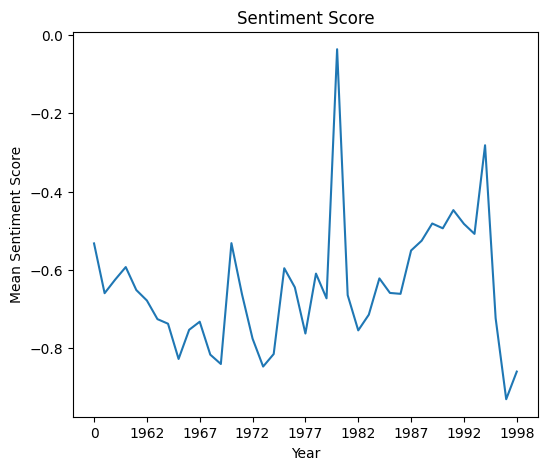

In [ ]:
#generate mean of sentiment_score by period
dfg = df_output.groupby(['Yr'])['sentiment_score'].mean()
dfg.index = dfg.index.astype(str).str.replace(r'\.0$', '', regex=True)
#create a bar plot
dfg.plot(kind='line', title='Sentiment Score', ylabel='Mean Sentiment Score',
         xlabel='Year', figsize=(6, 5))

This line plot shows the mean sentiment score across all provinces.

- decreased in 1960s
- small increase between 1968 and 1973
- sustantial increase between 1978 and 1980


<Axes: title={'center': 'sentiment_score'}, xlabel='Province', ylabel='Mean Sentiment Score'>

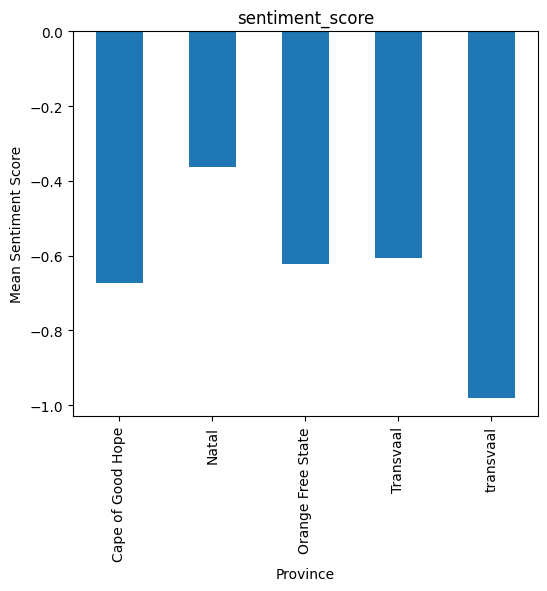

In [ ]:
dfg = df_output.groupby(['Province'])['sentiment_score'].mean()
dfg.plot(kind='bar', title='sentiment_score', ylabel='Mean Sentiment Score',
         xlabel='Province', figsize=(6, 5))

This dataset includes responses from 4 province. Studying the mean of sentiment scores for each province might reveal interesting insights to compare them against each other. The following code snippet plots the mean sentiment score for each province (Province on x-axis and mean of sentiment score for each province on y-axis).

As you can see, we have two bars for 'Transvaal' and 'transvaa' province. This shows that our data is not cleaned properly and we should merge these two together using the code snippet below and visualize it again.

<Axes: title={'center': 'sentiment_score'}, xlabel='Province', ylabel='Mean Sentiment Score'>

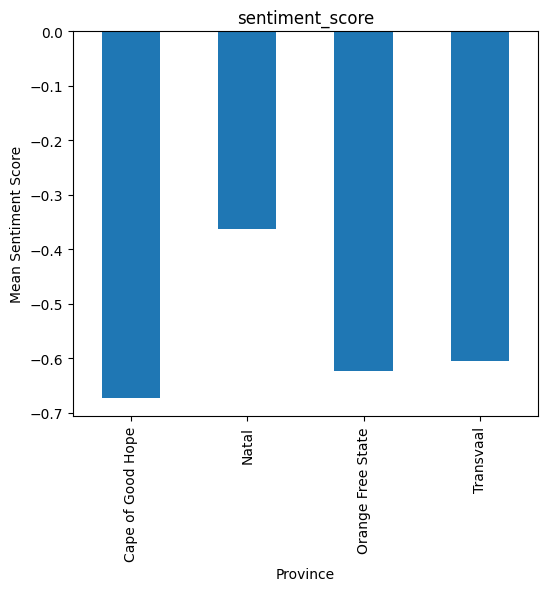

In [45]:
df_output['Province'] = df_output['Province'].replace('transvaal', 'Transvaal')

dfg = df_output.groupby(['Province'])['sentiment_score'].mean()
dfg.plot(kind='bar', title='sentiment_score', ylabel='Mean Sentiment Score',
         xlabel='Province', figsize=(6, 5))

Now, the bar plot shows that 'Natal' province had comparatively least amount of negative incidents compared to others.

([0, 1, 2, 3, 4],
 [Text(0, 0, 'Orange Free State'),
  Text(1, 0, 'Transvaal'),
  Text(2, 0, 'Cape of Good Hope'),
  Text(3, 0, 'Natal'),
  Text(4, 0, 'transvaal')])

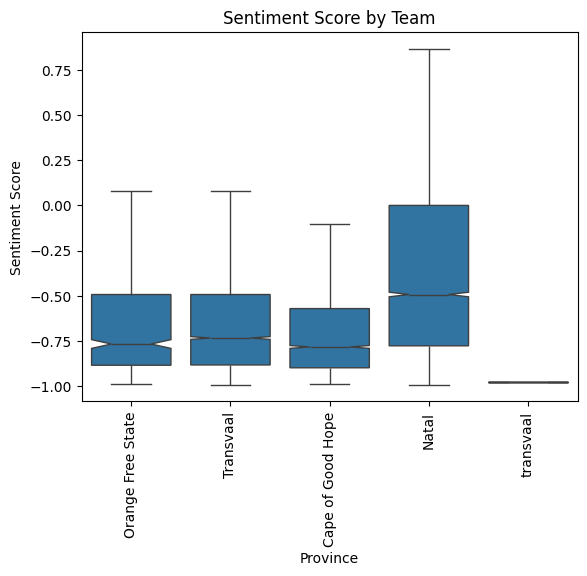

In [ ]:
import seaborn as sns
#create seaborn boxplots by group
sns.boxplot(x='Province', y='sentiment_score', notch = True,
            data=df_output, showfliers=False).set(title='Sentiment Score by Team')
#modify axis labels
plt.xlabel('Province')
plt.ylabel('Sentiment Score')
plt.xticks(rotation=90)

We visualize the same data here using the box plot.

### Let's redo the graphs using the Atair Package

In [ ]:
import altair as alt

# Prepare data for mean sentiment score by year
dfg_year = df_output.groupby('Yr')['sentiment_score'].mean().reset_index()
dfg_year['Yr'] = dfg_year['Yr'].astype(str).str.replace(r'\.0$', '', regex=True)

# Create the Altair bar chart for Sentiment Score by Year
chart_year = alt.Chart(dfg_year).mark_bar().encode(
    x=alt.X('Yr:N', title='Year'), # Use :N for nominal (categorical) data
    y=alt.Y('sentiment_score:Q', title='Mean Sentiment Score'),
    color=alt.Color('Yr:N', legend=alt.Legend(title="Year")),
    tooltip=['Yr', 'sentiment_score']
).properties(
    title='Mean Sentiment Score by Year'
).interactive()

chart_year

alt.Chart(...)

In [ ]:
import altair as alt

# Prepare data for mean sentiment score by province
dfg_province = df_output.groupby('Province')['sentiment_score'].mean().reset_index()

# Create the Altair bar chart for Sentiment Score by Province
chart_province = alt.Chart(dfg_province).mark_bar().encode(
    x=alt.X('Province:N', title='Province', sort='-y'), # Sort by sentiment score
    y=alt.Y('sentiment_score:Q', title='Mean Sentiment Score'),
    color=alt.Color('Province:N', legend=alt.Legend(title="Province")),
    tooltip=['Province', 'sentiment_score']
).properties(
    title='Mean Sentiment Score by Province'
).interactive()

chart_province

alt.Chart(...)

In [44]:
import altair as alt
alt.data_transformers.enable("vegafusion")

# Create the Altair box plot for Sentiment Score by Province
chart_boxplot = alt.Chart(df_output).mark_boxplot(extent='min-max', size=50).encode(
    x=alt.X('Province:N', title='Province', axis=alt.Axis(labels=False)), # Hide x-axis labels as they can overlap
    y=alt.Y('sentiment_score:Q', title='Sentiment Score'),
    color=alt.Color('Province:N', legend=alt.Legend(title="Province")),
    tooltip=['Province', 'sentiment_score']
).properties(
    title='Sentiment Score Distribution by Province'
).interactive()

chart_boxplot

alt.Chart(...)